### Importing libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ydata_profiling

In [128]:
# from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV


In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay

In [52]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
df.shape

(7043, 21)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Transformation

In [55]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [56]:
df.isna().sum()[df.isna().sum() > 0]

TotalCharges    11
dtype: int64

In [57]:
df=df.drop('customerID', axis=1)

### EDA

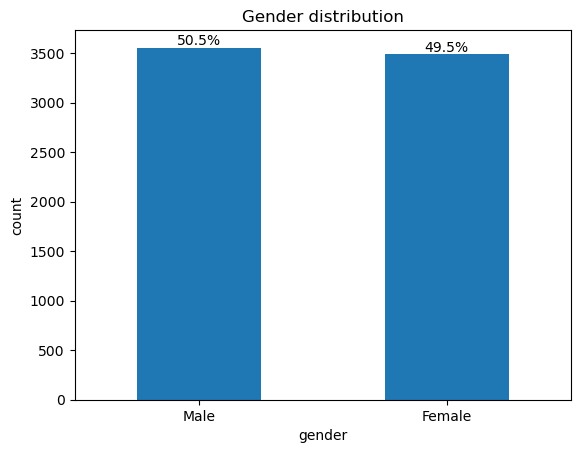

In [58]:
ax = df['gender'].value_counts().plot(kind='bar')

# axis labels
plt.xlabel('gender')
plt.ylabel('count')
plt.title('Gender distribution')
plt.xticks(rotation=0)

# total for percentage calculation
total = len(df)

# add % labels on top of bars
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{(count/total)*100:.1f}%'
    
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2, count),
                ha='center', va='bottom')

plt.show()


# Gender distribution is almost equal in dataset.

<Axes: xlabel='Dependents', ylabel='count'>

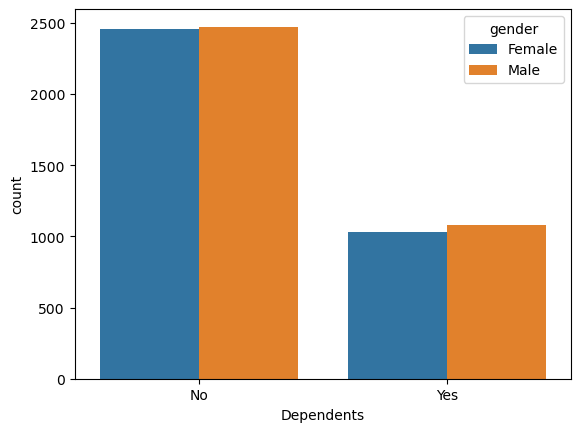

In [59]:
ax2 = (
    df['Dependents'].groupby(df['gender']).value_counts().reset_index(name='count')
)
sns.barplot(data=ax2, x='Dependents', y='count', hue='gender')

# Dependents distribution is not correlated with gender.

Partner,No,Yes
Dependents,,
No,90.085141,48.589065
Yes,9.914859,51.410935


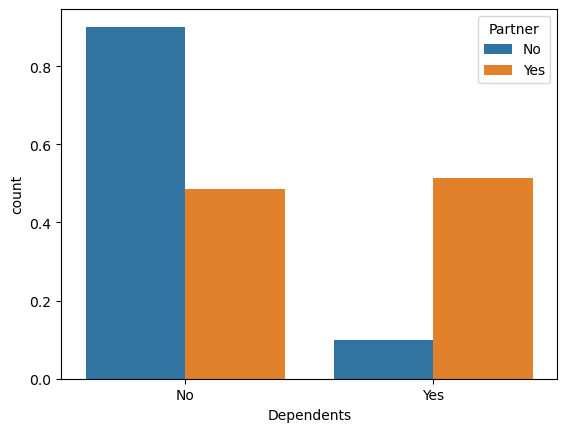

In [60]:
ax3 = (
    df['Dependents'].groupby(df['Partner']).value_counts(normalize=True).reset_index(name='count')
)

sns.barplot(data=ax3, x='Dependents', y='count', hue='Partner')
pd.crosstab(df['Dependents'], df['Partner'],  normalize = 'columns')*100

# 10% of customers have No partner but they are dependent.
# Customers with Partner have equal distribution of dependents and non-dependents.
# We cannot drop any of these columns as they are not highly correlated.

In [61]:
# Ydata profiling report for extensive EDA.

report= ydata_profiling.ProfileReport(df)
report.to_file('Telco_customer_report2.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 901.01it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [62]:
#  High correlation between MultipleLines and PhoneService
df['MultipleLines'].groupby(df['PhoneService']).value_counts(normalize=True).reset_index(name='percentage')

# We can drop PhoneService.
# as we can see if MultipleLines is Yes or No then PhoneService is Yes only.

df.drop('PhoneService',axis=1,inplace=True)


In [63]:
pd.crosstab(df['InternetService'], df['OnlineBackup'])
pd.crosstab(df['OnlineSecurity'], df['OnlineBackup'])

# No correlation between InternetService vs OnlineBackup and OnlineSecurity vs OnlineBackup.

OnlineBackup,No,No internet service,Yes
OnlineSecurity,,,
No,2195,0,1303
No internet service,0,1526,0
Yes,893,0,1126


In [64]:
df.groupby('InternetService')['MonthlyCharges'].mean().reset_index()

# Fiber optic is too expensive than DSL.

,InternetService,MonthlyCharges
0,DSL,58.102169
1,Fiber optic,91.500129
2,No,21.079194


In [65]:
# Shares of different InternetService
(df['InternetService'].value_counts(normalize=True)*100).reset_index()

# 44% of market has been captured by Fiber optic and 34% by DSL.
# But huge percentage of customers (22%) have no internet service. So we can target those customers for better marketing strategy.

,InternetService,proportion
0,Fiber optic,43.958540
1,DSL,34.374556
2,No,21.666903


In [66]:
df.groupby('InternetService')['tenure'].value_counts().reset_index().head(20)


,InternetService,tenure,count
0,DSL,1,212
1,DSL,72,133
2,DSL,2,82
3,DSL,3,71
4,DSL,71,62
5,DSL,4,61
6,DSL,70,52
7,DSL,7,46
8,DSL,5,43
9,DSL,8,43


In [67]:
df['Churn'].value_counts(normalize=True)*100

# In given data, Churn rate of customers is 26.5% which is quite high. 

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#### Churn EDA 

,Churn,count
0,No,5174
1,Yes,1869


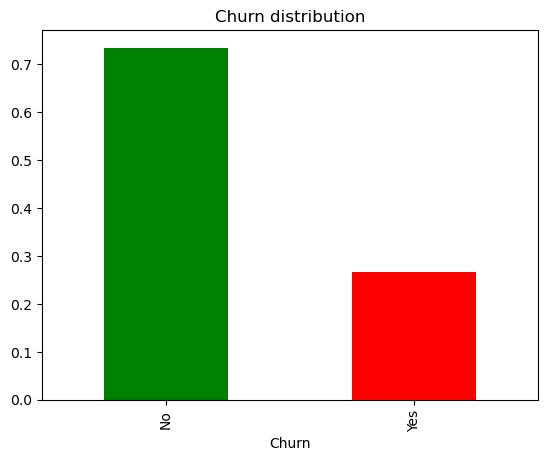

In [68]:
df['Churn'].value_counts(normalize=True).plot(kind='bar', color=['green', 'red'], title='Churn distribution')
df['Churn'].value_counts().reset_index(name='count')

# There are 73.5% customers who continue there services. Overall churn rate is 26.5%.

Contract,Month-to-month,One year,Two year
Churn,,,
No,0.572903,0.887305,0.971681
Yes,0.427097,0.112695,0.028319


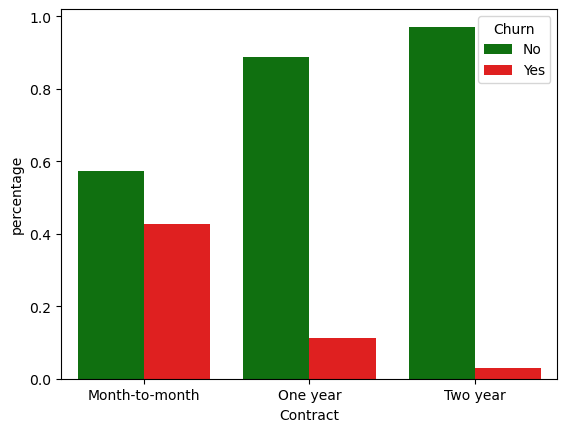

In [69]:
ax4 = df.groupby('Contract')['Churn'].value_counts(normalize=True).reset_index(name='percentage')
sns.barplot(data=ax4,
            x = 'Contract',
            y = 'percentage',
            hue = 'Churn',
            palette=['green', 'red']
            )
pd.crosstab(df['Churn'], df['Contract'],normalize='columns')


# As contract period increases, churn rate decreases. 
# Customers with month-to-month contract have highest churn rate (43%) and customers with two year contract have lowest churn rate (9%).

InternetService,DSL,Fiber optic,No
Churn,,,
No,81.040892,58.107235,92.59502
Yes,18.959108,41.892765,7.40498


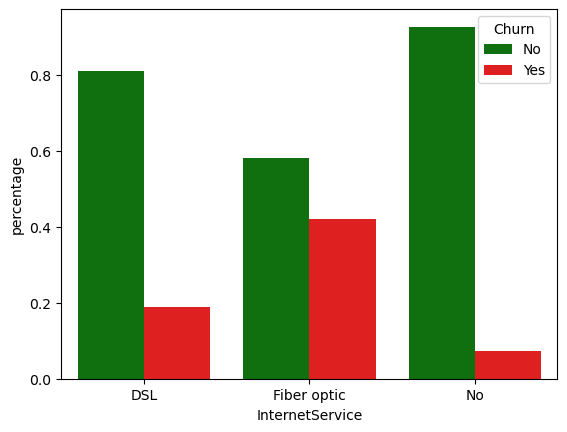

In [70]:
ax5 = df.groupby('InternetService')['Churn'].value_counts(normalize=True).reset_index(name='percentage')

sns.barplot(data=ax5,
            x='InternetService',
            y='percentage',
            errorbar=None,
            hue='Churn',
            palette=['green', 'red']
            )

pd.crosstab(df['Churn'], df['InternetService'], normalize='columns')*100
# ax5

# Customers with Fiber optic have the highest churn rate (42%)
# DSL customer have higher loyalty (81%) than Fiber optic (58%).

<Axes: xlabel='Churn', ylabel='tenure'>

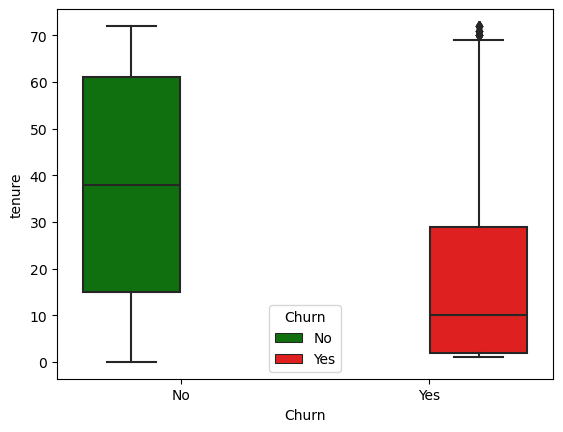

In [71]:
ax6 = df[['tenure', 'Churn']]
sns.boxplot(data=ax6,
                x='Churn',
                y='tenure',
                hue='Churn',
                palette=['green', 'red']
                )

# Higher tenures have high loyalty rate.
# There are some outliers in tenure column for customers who have churned. 

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

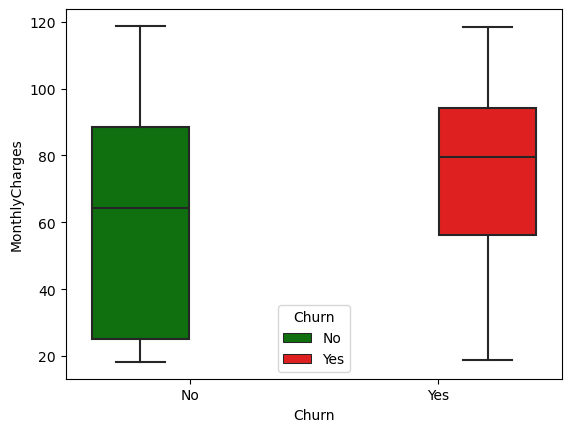

In [72]:
ax7 = df[['MonthlyCharges', 'Churn']]
sns.boxplot(data=ax7,
                x='Churn',
                y='MonthlyCharges',
                hue='Churn',
                palette=['green', 'red']
                )

# High monthly charges have high churn rate. So we can target those customers with better offers and discounts to reduce churn rate.

<Axes: xlabel='Churn', ylabel='TotalCharges'>

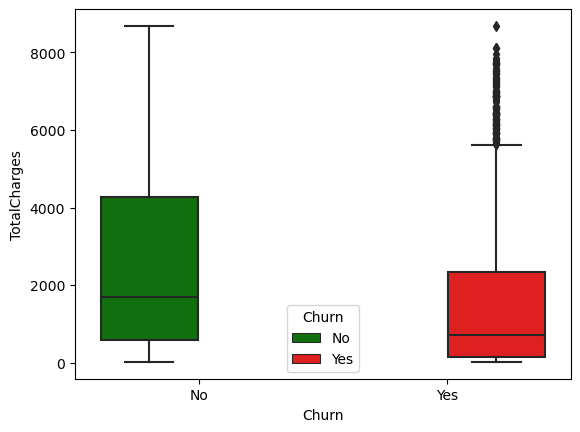

In [73]:
ax8 = df[['TotalCharges', 'Churn']]
sns.boxplot(data=ax8,
                x='Churn',
                y='TotalCharges',
                hue='Churn',
                palette=['green', 'red']
                )
# High total charges have high churn rate. 

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,83.290155,84.756899,54.714588,80.8933
Yes,16.709845,15.243101,45.285412,19.1067


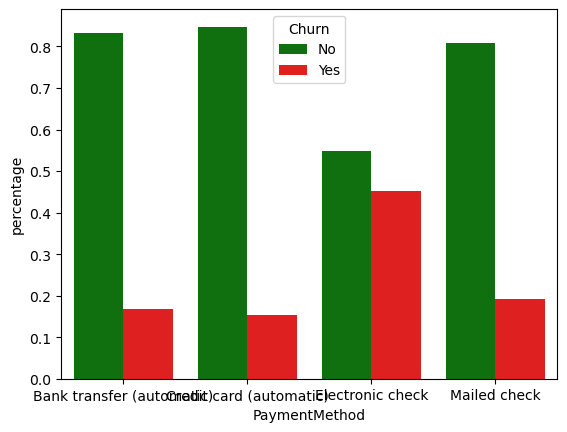

In [74]:
ax8 = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).reset_index(name='percentage')

sns.barplot(data=ax8,
            x='PaymentMethod',
            y='percentage',
            hue='Churn',
            palette=['green', 'red'],
            
            )

pd.crosstab(df['Churn'], df['PaymentMethod'], normalize='columns')*100

# Customers with Electronic check payment method have the highest churn rate (35%) and customers with Credit card payment method have the lowest churn rate (20%).

In [75]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72])

In [76]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

### Standardization

<Axes: ylabel='Density'>

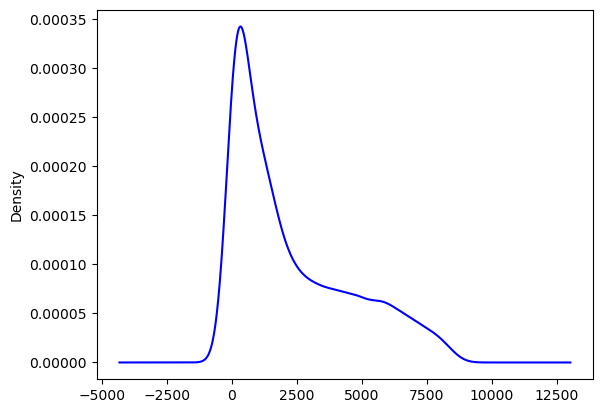

In [77]:
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)
df['TotalCharges']=df['TotalCharges'].astype(int)
df['TotalCharges'].plot(kind='kde', color='blue', label='TotalCharges')

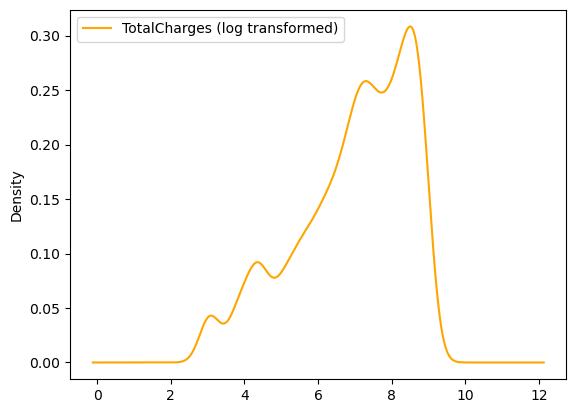

In [78]:
df['TotalCharges'] = np.log(df['TotalCharges'] + 1)
df['TotalCharges'].plot(kind='kde', color='orange', label='TotalCharges (log transformed)')
plt.legend()

### Train Test split

In [79]:
x= df.drop(['Churn'], axis=1)
y= df['Churn']

In [80]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

### Feature Engineering

In [81]:
le = LabelEncoder()
le.fit(y_train)

LabelEncoder()

In [82]:
y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [83]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [84]:
# Ordinal encoding for categorical columns.

oe = OrdinalEncoder(categories=[
    ['Female', 'Male'],                          # gender
    ['No', 'Yes'],                               # Partner
    ['No', 'Yes'],                               # Dependents
    ['No', 'Yes', 'No phone service'],           # MultipleLines
    ['No', 'DSL', 'Fiber optic'],                # InternetService 
    ['No', 'Yes', 'No internet service'],        # OnlineSecurity
    ['No', 'Yes', 'No internet service'],        # OnlineBackup
    ['No', 'Yes', 'No internet service'],        # DeviceProtection
    ['No', 'Yes', 'No internet service'],        # TechSupport
    ['No', 'Yes', 'No internet service'],        # StreamingTV
    ['No', 'Yes', 'No internet service'],        # StreamingMovies
    ['Month-to-month', 'One year', 'Two year'],  # Contract
    ['No', 'Yes'],                               # PaperlessBilling
    ['Bank transfer (automatic)', 'Mailed check', 'Electronic check', 'Credit card (automatic)']  # PaymentMethod
])

oe.fit(x_train.drop(['tenure', 'SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'tenure_group'], axis=1))

OrdinalEncoder(categories=[['Female', 'Male'], ['No', 'Yes'], ['No', 'Yes'],
                           ['No', 'Yes', 'No phone service'],
                           ['No', 'DSL', 'Fiber optic'],
                           ['No', 'Yes', 'No internet service'],
                           ['No', 'Yes', 'No internet service'],
                           ['No', 'Yes', 'No internet service'],
                           ['No', 'Yes', 'No internet service'],
                           ['No', 'Yes', 'No internet service'],
                           ['No', 'Yes', 'No internet service'],
                           ['Month-to-month', 'One year', 'Two year'],
                           ['No', 'Yes'],
                           ['Bank transfer (automatic)', 'Mailed check',
                            'Electronic check', 'Credit card (automatic)']])

In [85]:
x_train_oe = oe.transform(x_train.drop(['tenure', 'SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'tenure_group'], axis=1))
x_test_oe = oe.transform(x_test.drop(['tenure', 'SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'tenure_group'], axis=1))

## Models

### Decision Tree

In [114]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_oe, y_train)


DecisionTreeClassifier(random_state=42)

In [115]:
y_pred = dt.predict(x_test_oe)
accuracy_score(y_test, y_pred)

0.7295954577714692

#### By using One hot encoding

In [116]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
x_train_oh = ohe.fit_transform(x_train)
x_test_oh = ohe.transform(x_test)

In [117]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_oh, y_train)
y_pred_oh = dt.predict(x_test_oh)
accuracy_score(y_test, y_pred_oh)

0.7714691270404542

In [118]:
# Removing features with low importance and high cardinality to reduce dimensionality.
x_train_sel = x_train.drop(['Dependents', 'tenure', 'MultipleLines','gender', 'PaperlessBilling', 'SeniorCitizen'], axis=1)
x_test_sel = x_test.drop(['Dependents', 'tenure', 'MultipleLines','gender', 'PaperlessBilling', 'SeniorCitizen'], axis=1)

In [119]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
x_train_sel_oh = ohe.fit_transform(x_train_sel)
x_test_sel_oh = ohe.transform(x_test_sel)

In [120]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_sel_oh, y_train)
y_pred_sel_oh = dt.predict(x_test_sel_oh)
accuracy_score(y_test, y_pred_sel_oh)

0.7778566359119943

### Logistic Regression

In [121]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(x_train_sel_oh, y_train)
y_pred_clf = clf.predict(x_test_sel_oh)
accuracy_score(y_test, y_pred_clf)


0.7906316536550745

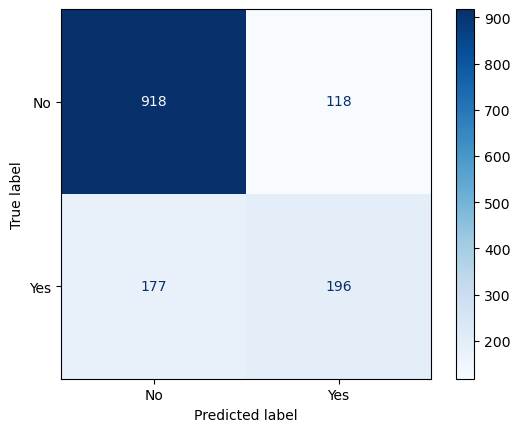

In [122]:
cm = confusion_matrix(y_test, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# FN is very high which is not good for business as we are predicting those customers as loyal who are actually going to churn. 
# So we need to reduce FN by tuning the model and using better algorithms.

In [163]:
pd.DataFrame(classification_report(y_test, y_pred_clf, target_names=le.classes_, output_dict=True)).transpose()

#"Yes" has very low all classifiction metrics. We have to improve model specifically for "Yes".

,precision,recall,f1-score,support
No,0.838356,0.886100,0.861567,1036.000000
Yes,0.624204,0.525469,0.570597,373.000000
accuracy,0.790632,0.790632,0.790632,0.790632
macro avg,0.731280,0.705785,0.716082,1409.000000
weighted avg,0.781664,0.790632,0.784540,1409.000000


#### Weight balancing

In [142]:
clf2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf2.fit(x_train_sel_oh, y_train)
y_pred_clf2 = clf2.predict(x_test_sel_oh)
accuracy_score(y_test, y_pred_clf2)

0.7565649396735273

In [165]:
pd.DataFrame(classification_report(y_test, y_pred_clf2, target_names=le.classes_, output_dict=True)).transpose()
# By balancing the classes, we have improved recall and f1-score for "Yes" class.

,precision,recall,f1-score,support
No,0.894198,0.758687,0.820888,1036.000000
Yes,0.528302,0.750670,0.620155,373.000000
accuracy,0.756565,0.756565,0.756565,0.756565
macro avg,0.711250,0.754679,0.720521,1409.000000
weighted avg,0.797335,0.756565,0.767748,1409.000000


### GridSerchCV

In [130]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

In [151]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid.fit(x_train_sel_oh, y_train)
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best cross-validation score: 0.8088227424749164


In [152]:
param_grid_updated = {
    'max_depth': 7,
    'min_samples_split': 20,
    'min_samples_leaf': 5,
    'criterion': 'gini'
}

model = RandomForestClassifier(random_state=42, class_weight='balanced', **param_grid_updated)
model.fit(x_train_sel_oh, y_train)
y_pred_model = model.predict(x_test_sel_oh)
accuracy_score(y_test, y_pred_model)

0.7203690560681334

In [166]:
pd.DataFrame(classification_report(y_test, y_pred_model, target_names=le.classes_, output_dict=True)).transpose()

,precision,recall,f1-score,support
No,0.926862,0.672780,0.779642,1036.000000
Yes,0.484018,0.852547,0.617476,373.000000
accuracy,0.720369,0.720369,0.720369,0.720369
macro avg,0.705440,0.762663,0.698559,1409.000000
weighted avg,0.809629,0.720369,0.736712,1409.000000


### SGDC

In [162]:
te = SGDClassifier(max_iter=100, random_state=42, eta0=0.01)
te.fit(x_train_sel_oh, y_train)
y_pred_sgdc = te.predict(x_test_sel_oh)
accuracy_score(y_test, y_pred_sgdc)

0.7700496806245565

In [160]:
pd.DataFrame(classification_report(y_test, y_pred_sgdc, target_names=le.classes_, output_dict=True))

,No,Yes,accuracy,macro avg,weighted avg
precision,0.820144,0.582492,0.77005,0.701318,0.757231
recall,0.880309,0.463807,0.77005,0.672058,0.770050
f1-score,0.849162,0.516418,0.77005,0.682790,0.761076
support,1036.000000,373.000000,0.77005,1409.000000,1409.000000


### Ensemble Algorithm